In [52]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from sklearn.cluster import DBSCAN

In [53]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [54]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


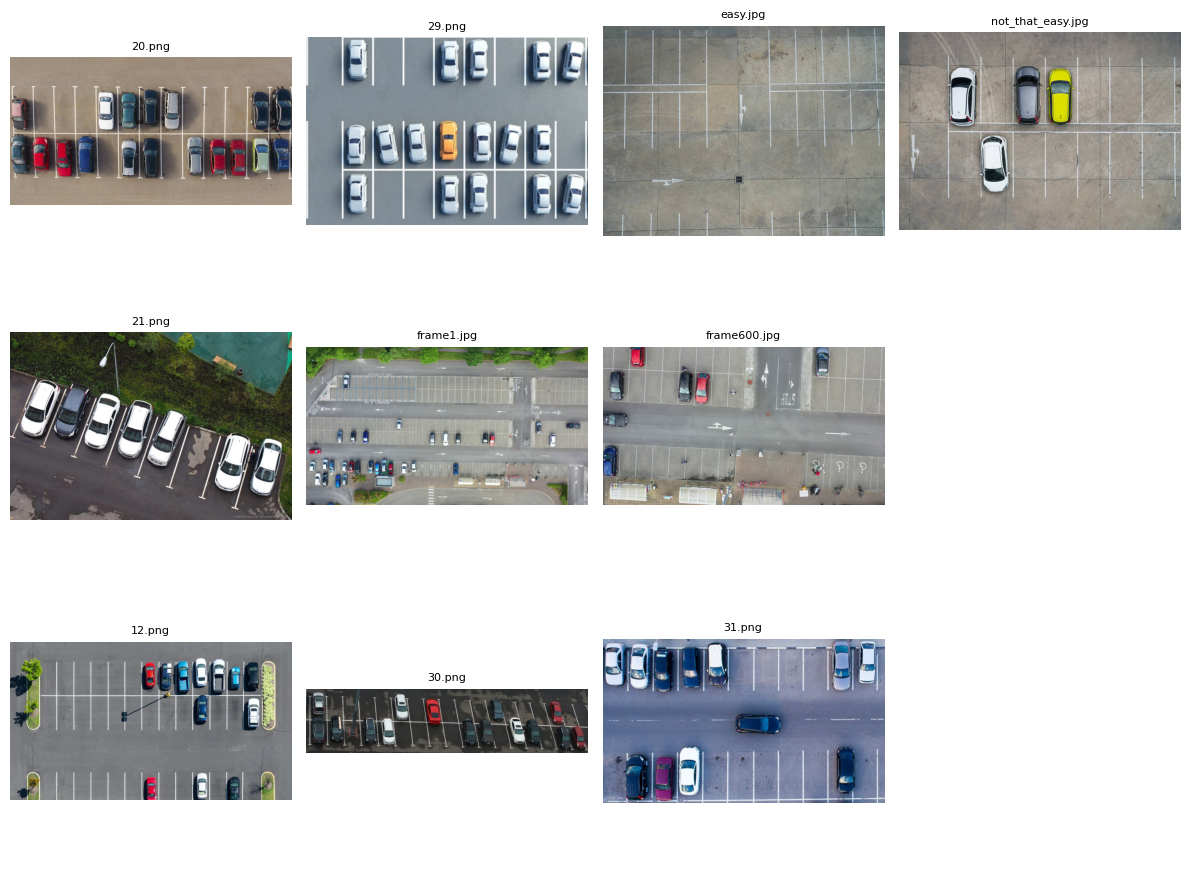

In [55]:
def resize_long_side(img, set_idx, img_idx, long_side=1024):
    """
    Resize image so its longest side = long_side.
    Returns ONLY the resized NumPy image (same structure as original code expects).
    """
    # convert PIL -> numpy if needed
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = img

    h, w = arr.shape[:2]
    scale = long_side / max(h, w)

    new_w = int(w * scale)
    new_h = int(h * scale)

    proc = cv2.resize(arr, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return proc

resized_images = {}
apply_technique(images, resized_images, resize_long_side)
print_pics(resized_images)

In [62]:
# Function to do the pipeline on the whole image.
def do_pipeline(img):

    # --- PREPROCESSING ---
    img_gray = convert_to_greyscale(img)
    # img_eq   = enhance_contrast(img_gray)
    # img_blur = blur_image(img_eq)

    # # --- FEATURE EXTRACTION ---
    # img_edges     = edge_detection(img_blur)            # Canny
    # img_gradients = compute_gradients(img_blur)         # optional
    # img_sharpened = edge_enhancement(img_gradients)     # optional

    # # --- STRUCTURAL ANALYSIS ---
    # lines = detect_lines(img_edges)                     # Hough Transform
    # corners = detect_corners(img_eq)                    # Harris / Shi-Tomasi
    # features = detect_local_features(img_eq)            # SIFT/SURF (optional)

    # # --- PARKING ZONE / ROI EXTRACTION ---
    # parking_zones = find_parking_zones(lines, corners)
    # # OR manual parking_zones = load_manual_zones()  (fallback)

    # # --- PROCESS EACH PARKING ZONE ---
    # all_spots = []
    # for zone in parking_zones:

    #     zone_img = crop_zone(img, zone)

    #     # geometric structure inside zone
    #     zone_lines = detect_lines(zone_img)
    #     spot_candidates = segment_parking_spots(zone_img, zone_lines)

    #     # refine candidate spots
    #     refined_spots = filter_and_validate_spots(spot_candidates)

    #     all_spots.extend(refined_spots)

    # # --- OCCUPANCY CLASSIFICATION ---
    # results = []
    # for spot in all_spots:

    #     spot_img = crop_spot(img, spot)

    #     # preprocessing per spot
    #     spot_gray = convert_to_grayscale(spot_img)
    #     spot_eq   = enhance_contrast(spot_gray)

    #     # detect if car is present
    #     occupancy_features = extract_occupancy_features(spot_eq)
    #     occupied = classify_occupancy(occupancy_features)

    #     results.append((spot, occupied))

    # # --- VISUALISATION OF OUTPUT ---
    # output_img = draw_detected_spots(img, results)

    return results, output_img

In [63]:
do_pipeline(images["easy"]["29.png"])

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [59]:
def convert_to_greyscale(img):
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Display output image
    plt.figure(figsize=(6,6))
    plt.imshow(grey, cmap='gray')
    plt.title("Greyscale Output")
    plt.axis('off')

    return gray